# Generate contralateral breasts for hand-picked samples

Run trained **CUT / FastCUT** generators live on a few specific VinDr studies (no full dataset)
and save the synthesized opposite-laterality breasts.

This fork trains a **single shared generator** `netG` in an **aligned frame** (the right breast is
flipped + width-cropped to the left orientation, normalized to `[-1, 1]` — exactly what training
saw). So both directions come from the same network:

- `fake_right = G(real_left)` — synthesize the **right** breast from the real **left**.
- `fake_left  = G(real_right_aligned)` — synthesize the **left** breast from the real **right**.

For each model × sample we save `real_left`, `real_right_aligned`, `fake_right_from_left`,
`fake_left_from_right`, and a 2×2 `comparison.png`, under `laterality_samples/<model>/<label>/`.

**Notes**
- Outputs are in the **aligned (left-orientation) frame** — what the model emits. To view
  `fake_right_from_left` in true-right orientation, horizontally flip it (`cv2.flip(img, 1)`).
- Per-model geometry/architecture (size, crop, `flip_right`, `netG`, masking) is recovered from
  each `checkpoints/<name>/train_opt.txt`, so the notebook adapts per checkpoint.
- This works for any checkpoint; for a strictly **unidirectional** run, feeding the right breast
  to `netG` is mildly out-of-domain (the model was only trained left→right).

**Sections** — 0 Config · 1 Helpers · 2 Dry check (no weights) · 3 Inference · 4 Display

In [1]:
# ============================ 0. Config ============================
import os, sys
from pathlib import Path

# --- locate repo root so `import data.bilateral` works ---
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data" / "bilateral.py").exists():
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "data" / "bilateral.py").exists():
            REPO_ROOT = p
            break
sys.path.insert(0, str(REPO_ROOT))

import torch

# --- data / artifact locations ---
DATA_ROOT       = "/home/valery/datasets/vindr/images"
ANNOTATIONS_CSV = "/home/valery/datasets/vindr/finding_annotations.csv"
CHECKPOINTS_DIR = REPO_ROOT / "checkpoints"
OUTPUT_DIR      = REPO_ROOT / "laterality_samples"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- models to run: checkpoint dir names under checkpoints/<name>/ ---
# Each needs <epoch>_net_G.pth plus train_opt.txt (used to recover geometry/arch).
# Drop the trained weights into checkpoints/<name>/ before running section 3.
MODELS = [
    {"name": "vindr_cut_scheduled_ddp_g5", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    {"name": "vindr_cut_unpaired_bilateral_ddp2", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    # {"name": "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l10_l25_20260612", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    # {"name": "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l15_l20_20260614", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    {"name": "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    {"name": "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
    {"name": "vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625", "epoch": "latest"},   # <-- replace / extend with your CUT/FastCUT runs
]

# --- the 3 hand-picked samples: study_id + explicit L-CC and R-CC image ids ---
# PNGs are read from DATA_ROOT/<study_id>/<image_id>.png
#
# Known-good examples found in finding_annotations.csv (right-CC No Finding / Mass / Susp Calc),
# handy as a quick sanity test of the format and pipeline:
#   no_finding: study 3d7a29f366f2cc2c0aec860490172e48  L d226e9c76c75482ef38e3a7b4b575c69  R f76724caf360a41ba8030579efc8afd8
#   right_mass: study b96bf19eae6ad53b79889034d67a0011  L 6c1c007b3ef400196ece12f27662b2de  R d0b5c4ed2cbf8e9712af6bce9df87e6d
#   right_calc: study d6c5932b95b9f03f4a70dc627ac7b8de  L cf304b6c5ce61a389943b4773359666b  R 7e279279174120a7bd49d2e142c0bac6
SAMPLES = [
    {"label": "no_finding", "study_id": "941abd031945caafe2cd9215675b1e06",
     "left_image_id": "0048c48d3a3cb19da00ffed4457ab8b5", "right_image_id": "8b9c34a09956139aaa875aef74dadf97"},
  {"label": "right_mass", "study_id": "008b8e61390fcb4c0873258c15b0a53a",
     "left_image_id": "b25443ab817d5590d25b733c1e59192d", "right_image_id": "f1f79501410a98782c0a03b48e66df83"},
    {"label": "right_calc", "study_id": "0ee32f5c910b35c30a500c82c7b1c2d1",
     "left_image_id": "216bcdbcf4b0a44d8c1bef2e6c0de16e", "right_image_id": "26dd42f1a4341cdf6feebd22564f8939"},
     ]

print("repo root  :", REPO_ROOT)
print("device     :", DEVICE)
print("checkpoints:", CHECKPOINTS_DIR)
print("output dir :", OUTPUT_DIR)

repo root  : /home/valery/phd/contrastive-unpaired-translation
device     : cuda
checkpoints: /home/valery/phd/contrastive-unpaired-translation/checkpoints
output dir : /home/valery/phd/contrastive-unpaired-translation/laterality_samples


In [2]:
# ============================ 1. Helpers ============================
import csv
from functools import lru_cache

import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Reuse the project's loaders so geometry / normalization match training exactly.
from data.bilateral import _load_image, _load_mask, _mask_path
from models import networks
import util.util as util


# ---- sample resolution -------------------------------------------------------
@lru_cache(maxsize=1)
def _finding_by_image_id():
    # image_id -> finding_categories string (used only for the panel caption)
    out = {}
    with open(ANNOTATIONS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            out.setdefault(row["image_id"], row["finding_categories"])
    return out


def resolve_sample(sample):
    # Build the L-CC / R-CC PNG paths from the supplied ids and verify they exist.
    sid = sample["study_id"]
    l_path = Path(DATA_ROOT) / sid / f"{sample['left_image_id']}.png"
    r_path = Path(DATA_ROOT) / sid / f"{sample['right_image_id']}.png"
    for tag, p in [("left", l_path), ("right", r_path)]:
        if not p.exists():
            raise FileNotFoundError(f"{sample['label']}: {tag} image not found: {p}")
    finding = _finding_by_image_id().get(sample["right_image_id"], "?")
    return {"label": sample["label"], "study_id": sid,
            "left_path": l_path, "right_path": r_path, "right_finding": finding}


# ---- per-model config from train_opt.txt ------------------------------------
def _coerce(s):
    s = s.strip()
    if s in ("True", "False"):
        return s == "True"
    if s == "None":
        return None
    # bilateral_size prints as a tuple "(512, 384)" (default) OR a list "[128, 96]"
    # (when overridden on the CLI via nargs=2) -- handle both bracket styles.
    if (s[:1], s[-1:]) in (("(", ")"), ("[", "]")):
        parts = [x for x in s[1:-1].split(",") if x.strip() != ""]
        try:
            return tuple(int(x) for x in parts)
        except ValueError:
            return s
    for cast in (int, float):
        try:
            return cast(s)
        except ValueError:
            pass
    return s


def parse_train_opt(name):
    # Parse checkpoints/<name>/train_opt.txt ("key: value [default: ...]") into a dict.
    path = CHECKPOINTS_DIR / name / "train_opt.txt"
    cfg = {}
    if path.exists():
        for line in path.read_text().splitlines():
            if ":" not in line:
                continue
            key, _, rest = line.partition(":")
            key = key.strip()
            if not key or " " in key:                  # skip "----- Options -----" banners
                continue
            val = rest.split("\t")[0].split("[default")[0]   # drop the [default: ...] note
            cfg[key] = _coerce(val)
    else:
        print(f"[warn] {path} not found; using defaults for {name}")
    # fill defaults for anything the file did not contain
    defaults = dict(netG="resnet_9blocks", input_nc=1, output_nc=1, ngf=64,
                    normG="instance", no_antialias=False, no_antialias_up=False,
                    bilateral_size=(512, 384), crop_width=360, flip_right=False,
                    bidirectional=False, masked_loss=False, mask_bg_value=-1.0,
                    mask_feather=3)
    for k, v in defaults.items():
        cfg.setdefault(k, v)
    bs = cfg["bilateral_size"]
    cfg["bilateral_size"] = tuple(bs) if isinstance(bs, (tuple, list)) else (bs, bs)
    return cfg


def build_generator(name, epoch, cfg):
    # Build netG from cfg and load <epoch>_net_G.pth (mirrors base_model.load_networks:
    # weights are saved unwrapped, so a plain load_state_dict is enough).
    ckpt = CHECKPOINTS_DIR / name / f"{epoch}_net_G.pth"
    if not ckpt.exists():
        raise FileNotFoundError(
            f"checkpoint not found: {ckpt}\n"
            f"    Drop the trained generator weights into checkpoints/{name}/ first.")
    netG = networks.define_G(
        cfg["input_nc"], cfg["output_nc"], cfg["ngf"], cfg["netG"], cfg["normG"],
        use_dropout=False, init_type="normal", init_gain=0.02,
        no_antialias=cfg["no_antialias"], no_antialias_up=cfg["no_antialias_up"],
        gpu_ids=[], opt=None,
    ).to(DEVICE)
    state = torch.load(str(ckpt), map_location=DEVICE)
    if hasattr(state, "_metadata"):
        del state._metadata
    netG.load_state_dict(state)
    netG.eval()
    return netG


# ---- masked-model input fidelity (mirrors CUTModel._feather / _apply_mask) ----
def _feather_kernel(r):
    ax = torch.arange(2 * r + 1, dtype=torch.float32) - r
    g = torch.exp(-(ax ** 2) / (2 * (r / 2.0) ** 2))
    g = g / g.sum()
    return (g[:, None] * g[None, :]).view(1, 1, 2 * r + 1, 2 * r + 1)


def apply_mask(x, mask, bg_value, feather):
    # x, mask: [1,1,H,W] on the same device. Blend foreground over a constant bg.
    if feather and feather > 0:
        r = int(feather)
        k = _feather_kernel(r).to(x.device, x.dtype)
        a = F.conv2d(F.pad(mask, (r, r, r, r), mode="replicate"), k)
    else:
        a = mask
    return x * a + bg_value * (1.0 - a)


def load_input(path, cfg, flip):
    # Load one breast into the model's [-1,1] aligned frame; mask it iff the model used masking.
    t = _load_image(Path(path), cfg["bilateral_size"], flip, cfg["crop_width"])  # [1,H,W]
    t = t.unsqueeze(0).to(DEVICE)                                                # [1,1,H,W]
    if cfg["masked_loss"]:
        m = _load_mask(_mask_path(Path(path)), cfg["bilateral_size"], flip, cfg["crop_width"])
        if m is not None:
            t = apply_mask(t, m.unsqueeze(0).to(DEVICE), cfg["mask_bg_value"], cfg["mask_feather"])
        else:
            print(f"[warn] masked_loss model but no mask for {Path(path).name}; using unmasked input")
    return t


def to_im(t):
    # [1,1,H,W] or [1,H,W] tensor in [-1,1] -> uint8 RGB numpy (util.tensor2im expects 4-D).
    if t.dim() == 3:
        t = t.unsqueeze(0)
    return util.tensor2im(t)


print("helpers ready")

helpers ready


## 2. Dry check (no weights needed)

Confirms the supplied sample ids resolve to real PNGs and that the preprocessing geometry is
what the first model expects — run this before dropping in any checkpoints.

In [3]:
# Resolve every sample and load both breasts in the first model's frame (no netG yet).
cfg0 = parse_train_opt(MODELS[0]["name"])
print(f"using geometry from '{MODELS[0]['name']}': size={cfg0['bilateral_size']} "
      f"crop_width={cfg0['crop_width']} flip_right={cfg0['flip_right']} "
      f"masked={cfg0['masked_loss']}\n")

for s in SAMPLES:
    try:
        r = resolve_sample(s)
    except FileNotFoundError as e:
        print("SKIP:", e)
        continue
    L = _load_image(r["left_path"],  cfg0["bilateral_size"], False, cfg0["crop_width"])
    R = _load_image(r["right_path"], cfg0["bilateral_size"], cfg0["flip_right"], cfg0["crop_width"])
    print(f"{s['label']:>12} | right finding={r['right_finding']!r:38} "
          f"| L {tuple(L.shape)} R {tuple(R.shape)} "
          f"range [{float(L.min()):.2f}, {float(L.max()):.2f}]")

using geometry from 'vindr_cut_scheduled_ddp_g5': size=(512, 384) crop_width=360 flip_right=True masked=False

  no_finding | right finding="['No Finding']"                       | L (1, 512, 360) R (1, 512, 360) range [-1.00, 0.77]
  right_mass | right finding="['Mass']"                             | L (1, 512, 360) R (1, 512, 360) range [-1.00, 0.40]
  right_calc | right finding="['Suspicious Calcification']"         | L (1, 512, 360) R (1, 512, 360) range [-1.00, 0.67]


## 3. Inference

For each model: load `netG` once, then for each sample synthesize both opposite-laterality
breasts and save the reals, the fakes, and a 2×2 comparison panel.

In [4]:
results = []  # (model_name, sample_label, comparison_path)

for m in MODELS:
    name, epoch = m["name"], m.get("epoch", "latest")
    cfg = parse_train_opt(name)
    print(f"\n=== model: {name} (epoch {epoch}) ===")
    print(f"    netG={cfg['netG']} size={cfg['bilateral_size']} crop_width={cfg['crop_width']} "
          f"flip_right={cfg['flip_right']} masked={cfg['masked_loss']} bidir={cfg['bidirectional']}")
    try:
        netG = build_generator(name, epoch, cfg)
    except FileNotFoundError as e:
        print("    SKIP model -", e)
        continue

    for s in SAMPLES:
        try:
            r = resolve_sample(s)
        except FileNotFoundError as e:
            print("    SKIP sample -", e)
            continue

        real_left  = load_input(r["left_path"],  cfg, flip=False)              # [1,1,H,W]
        real_right = load_input(r["right_path"], cfg, flip=cfg["flip_right"])  # aligned right
        with torch.no_grad():
            fake_right = netG(real_left)    # G(left)  -> synthetic right (aligned frame)
            fake_left  = netG(real_right)   # G(right) -> synthetic left

        out_dir = OUTPUT_DIR / name / s["label"]
        out_dir.mkdir(parents=True, exist_ok=True)
        util.save_image(to_im(real_left),  str(out_dir / "real_left.png"))
        util.save_image(to_im(real_right), str(out_dir / "real_right_aligned.png"))
        util.save_image(to_im(fake_right), str(out_dir / "fake_right_from_left.png"))
        util.save_image(to_im(fake_left),  str(out_dir / "fake_left_from_right.png"))

        # 2x2 comparison panel: reals (left col) vs generated opposite laterality (right col)
        fig, ax = plt.subplots(2, 2, figsize=(7, 9))
        ax[0, 0].imshow(to_im(real_left));  ax[0, 0].set_title("real left (A)")
        ax[0, 1].imshow(to_im(fake_right)); ax[0, 1].set_title("fake right = G(left)")
        ax[1, 0].imshow(to_im(real_right)); ax[1, 0].set_title("real right (aligned)")
        ax[1, 1].imshow(to_im(fake_left));  ax[1, 1].set_title("fake left = G(right)")
        for a in ax.ravel():
            a.set_xticks([]); a.set_yticks([])
        fig.suptitle(f"{name}\n{s['label']}  |  right finding: {r['right_finding']}", fontsize=10)
        fig.tight_layout()
        cmp_path = out_dir / "comparison.png"
        fig.savefig(cmp_path, dpi=120, bbox_inches="tight")
        plt.close(fig)

        results.append((name, s["label"], cmp_path))
        print(f"    saved {s['label']:>12} -> {out_dir}")

print(f"\ndone: {len(results)} (model, sample) panels")


=== model: vindr_cut_scheduled_ddp_g5 (epoch latest) ===
    netG=resnet_9blocks size=(512, 384) crop_width=360 flip_right=True masked=False bidir=False
    saved   no_finding -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/no_finding
    saved   right_mass -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/right_mass
    saved   right_calc -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/right_calc

=== model: vindr_cut_unpaired_bilateral_ddp2 (epoch latest) ===
    netG=resnet_9blocks size=(512, 384) crop_width=360 flip_right=True masked=False bidir=False
    saved   no_finding -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_unpaired_bilateral_ddp2/no_finding
    saved   right_mass -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_unpaired_bilateral_ddp2/right_mass
    sa

## 4. Display — per-study 3×3 grid

For each model × study, lay out a 3×3 grid (re-loading the saved aligned-frame PNGs, so this
cell runs on its own without re-running inference):

| | col 0 | col 1 | col 2 (diff) |
|---|---|---|---|
| **row 0** | real left | real right (aligned) | real L − real R  *(natural L/R asymmetry)* |
| **row 1** | fake right = G(L) | real right | fake R − real R  *(L→R error)* |
| **row 2** | real left | fake left = G(R) | real L − fake L  *(R→L error)* |

Diffs are signed (`seismic`, symmetric scale) with the mean-abs error in the title. **Finding
boxes** from `finding_annotations.csv` are mapped through the *same* geometry the model saw
(resize → flip → crop) and drawn on every cell of the matching laterality — right findings in
**yellow**, left findings in **cyan**. Each grid is also saved to `<out_dir>/study_grid.png`.

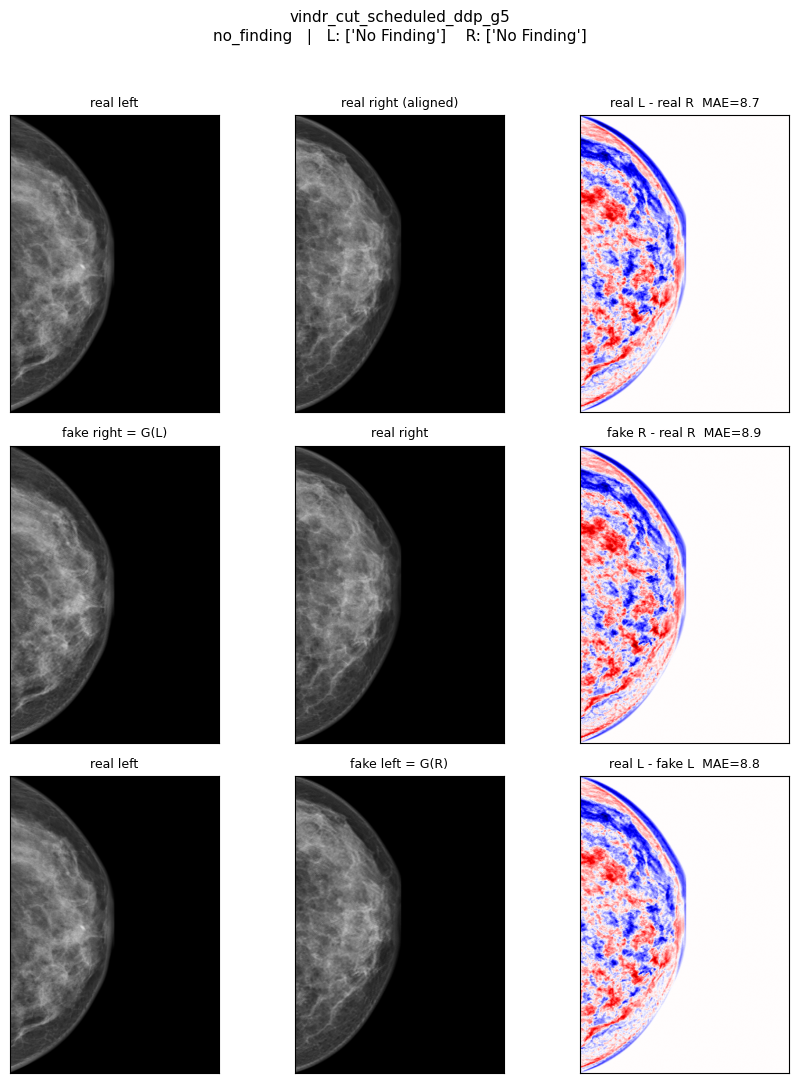

shown vindr_cut_scheduled_ddp_g5 / no_finding  (right boxes: 0, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/no_finding/study_grid.png


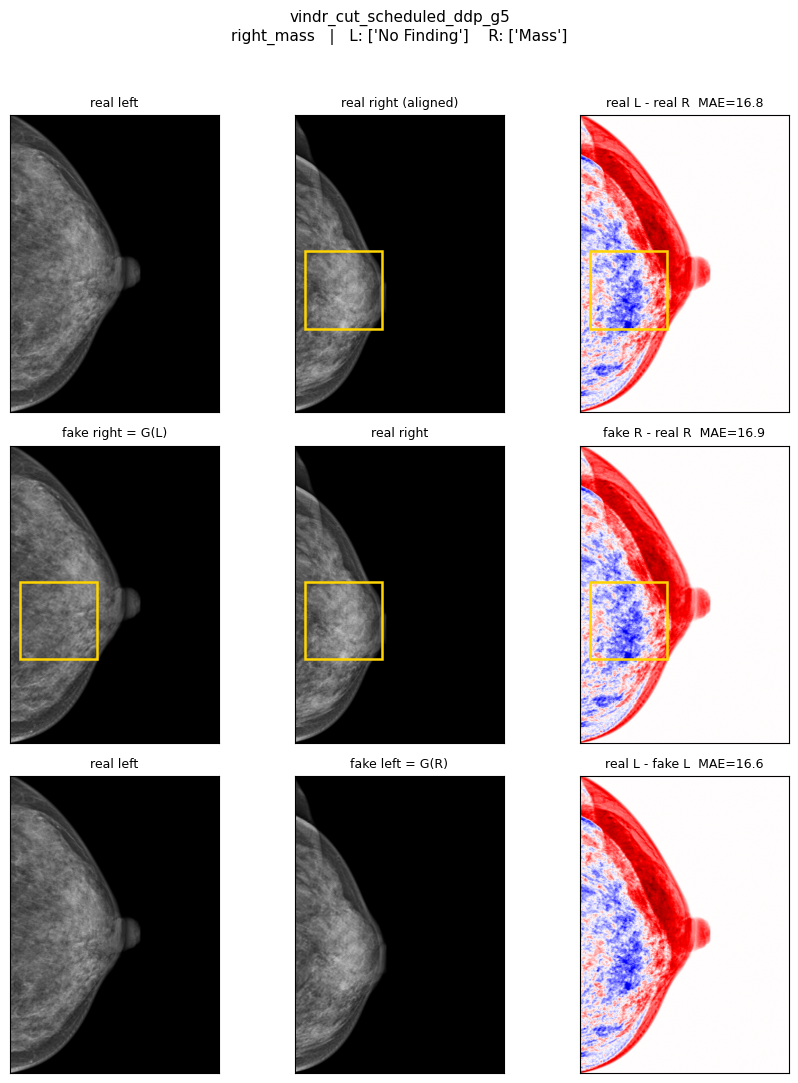

shown vindr_cut_scheduled_ddp_g5 / right_mass  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/right_mass/study_grid.png


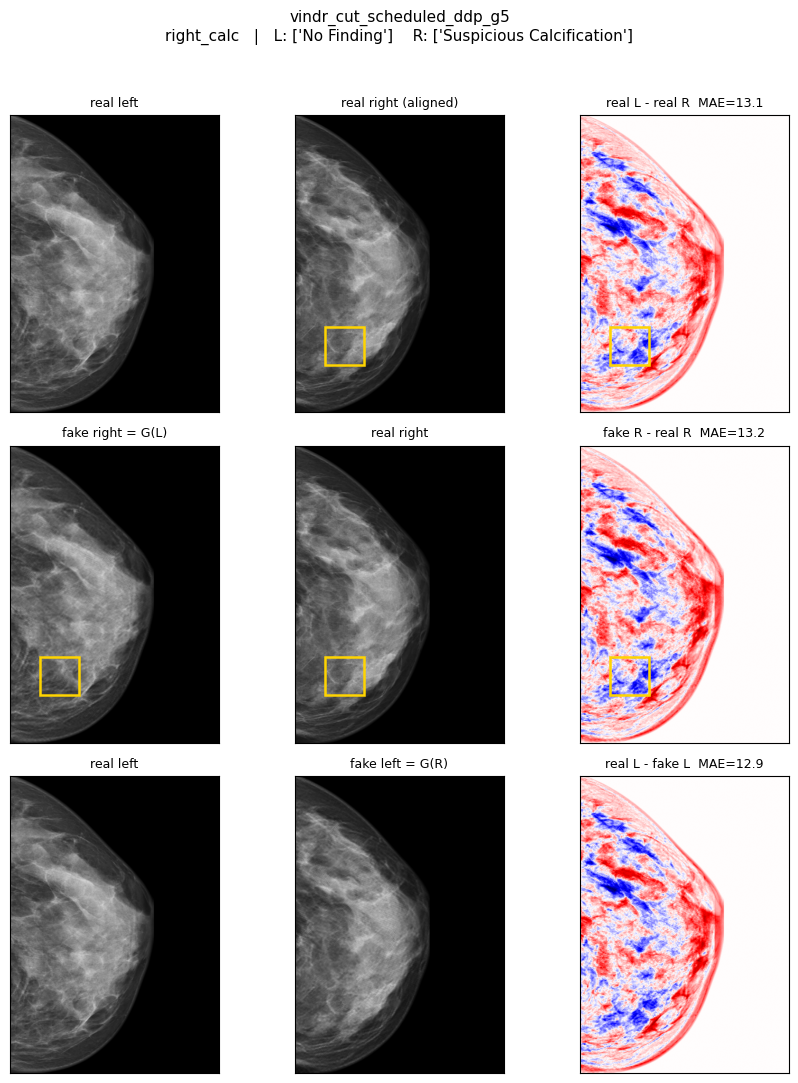

shown vindr_cut_scheduled_ddp_g5 / right_calc  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_scheduled_ddp_g5/right_calc/study_grid.png


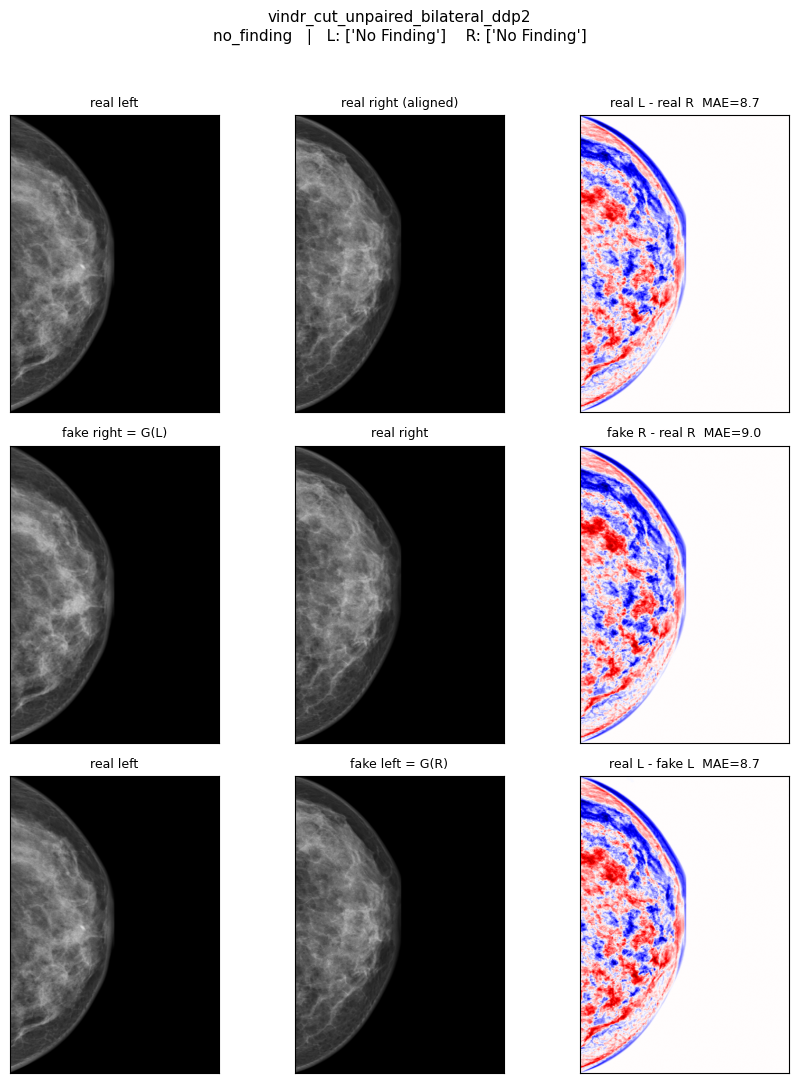

shown vindr_cut_unpaired_bilateral_ddp2 / no_finding  (right boxes: 0, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_unpaired_bilateral_ddp2/no_finding/study_grid.png


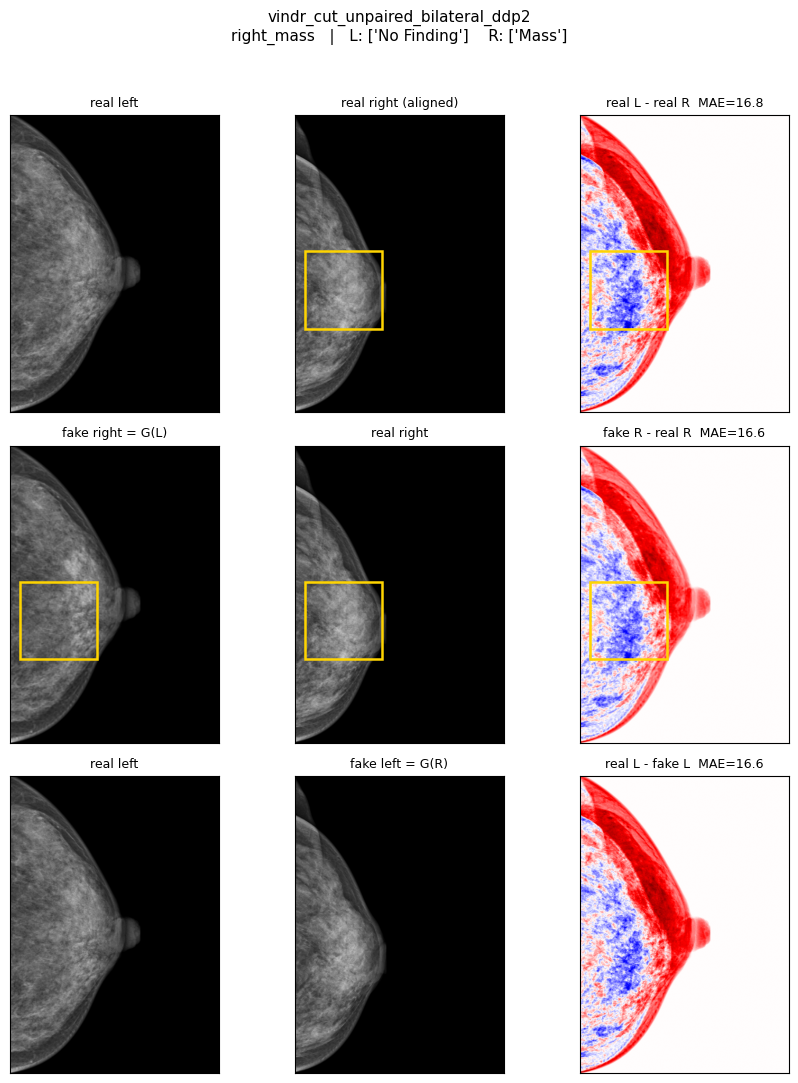

shown vindr_cut_unpaired_bilateral_ddp2 / right_mass  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_unpaired_bilateral_ddp2/right_mass/study_grid.png


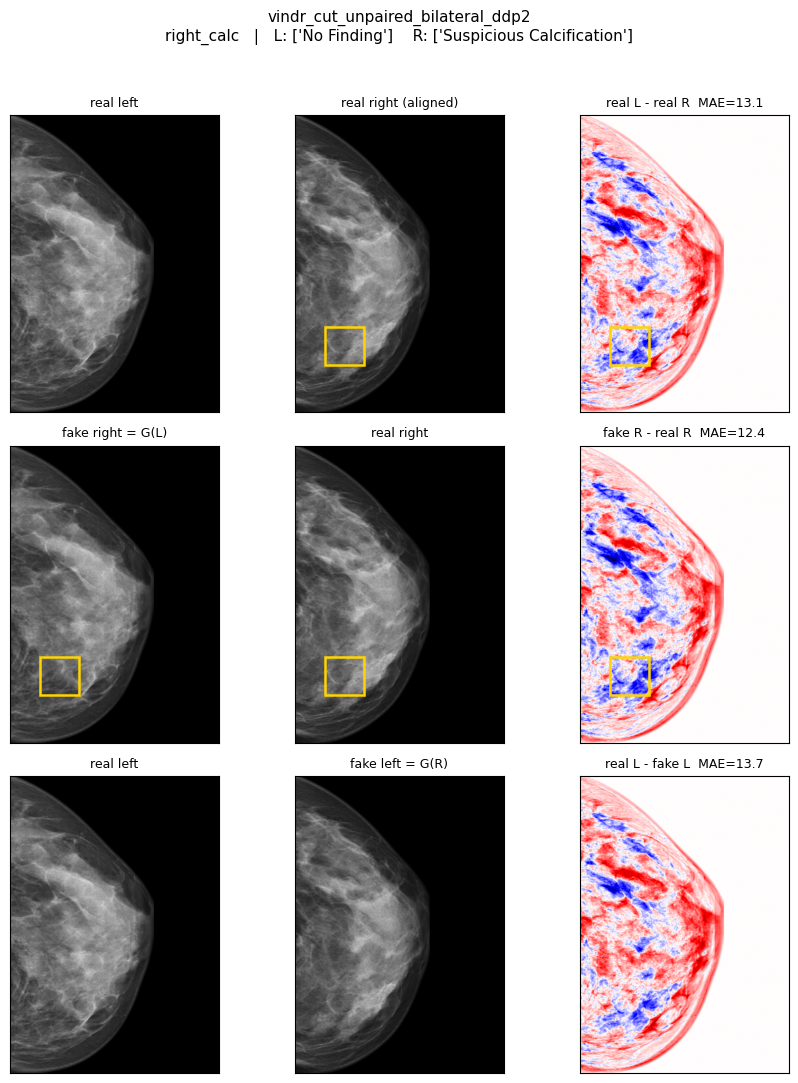

shown vindr_cut_unpaired_bilateral_ddp2 / right_calc  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_cut_unpaired_bilateral_ddp2/right_calc/study_grid.png


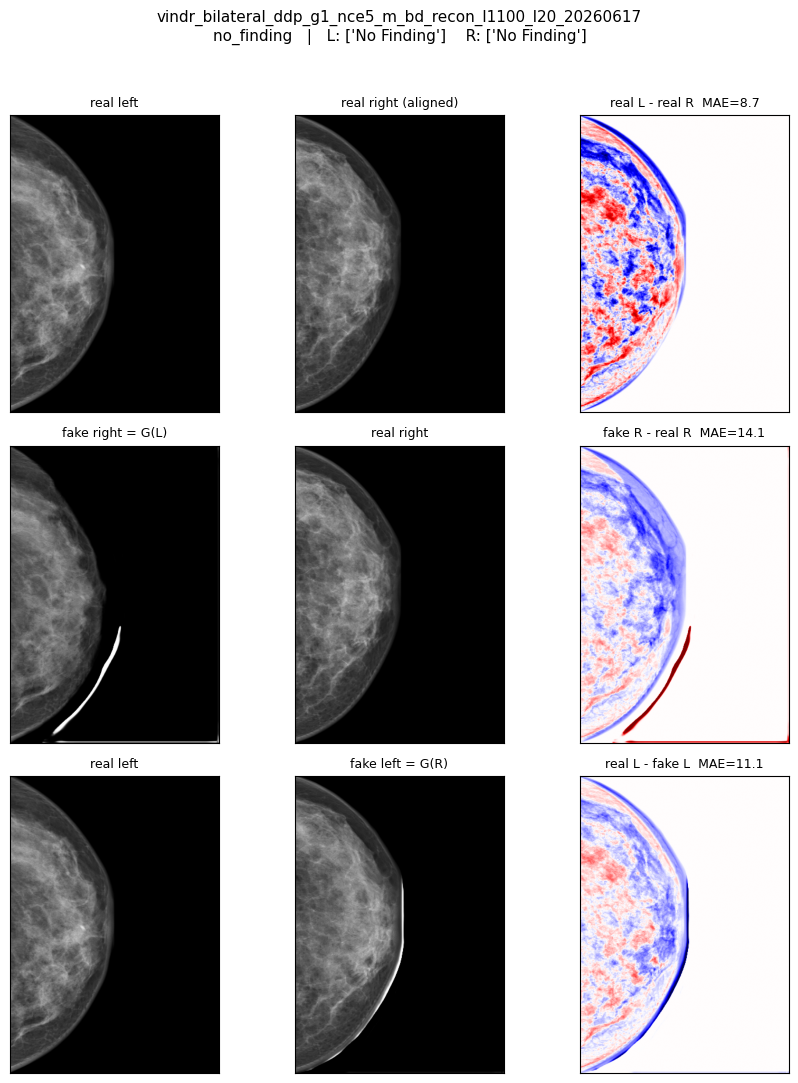

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617 / no_finding  (right boxes: 0, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617/no_finding/study_grid.png


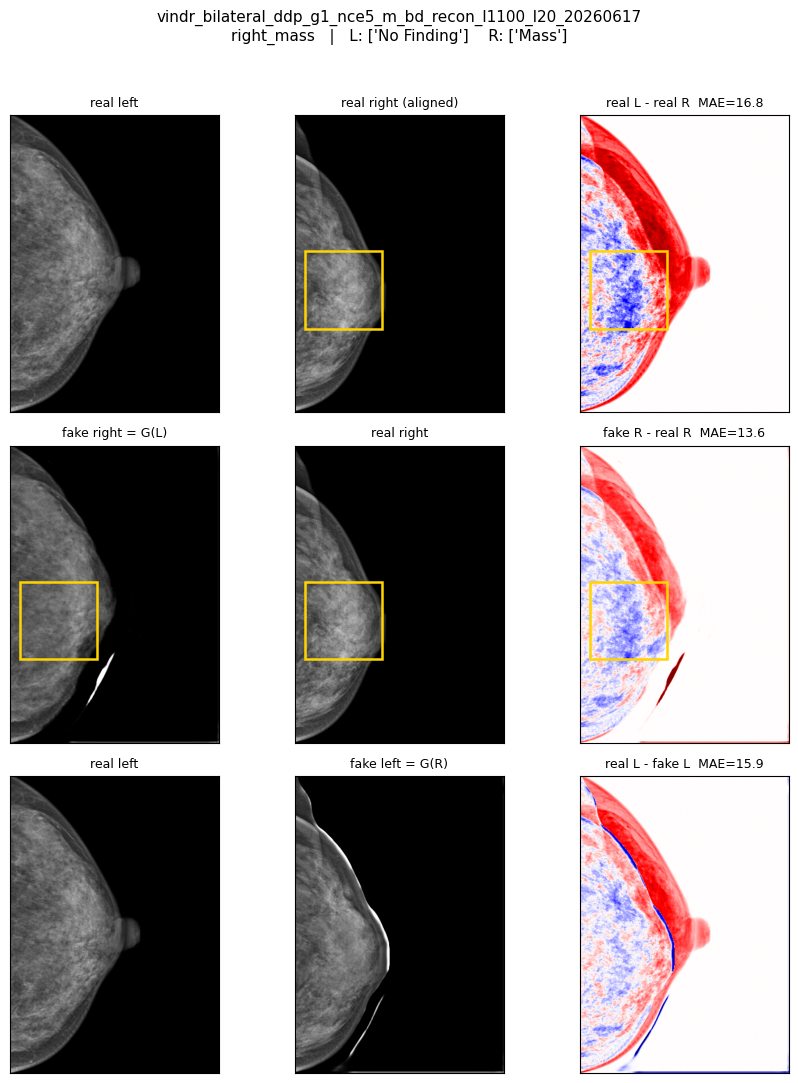

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617 / right_mass  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617/right_mass/study_grid.png


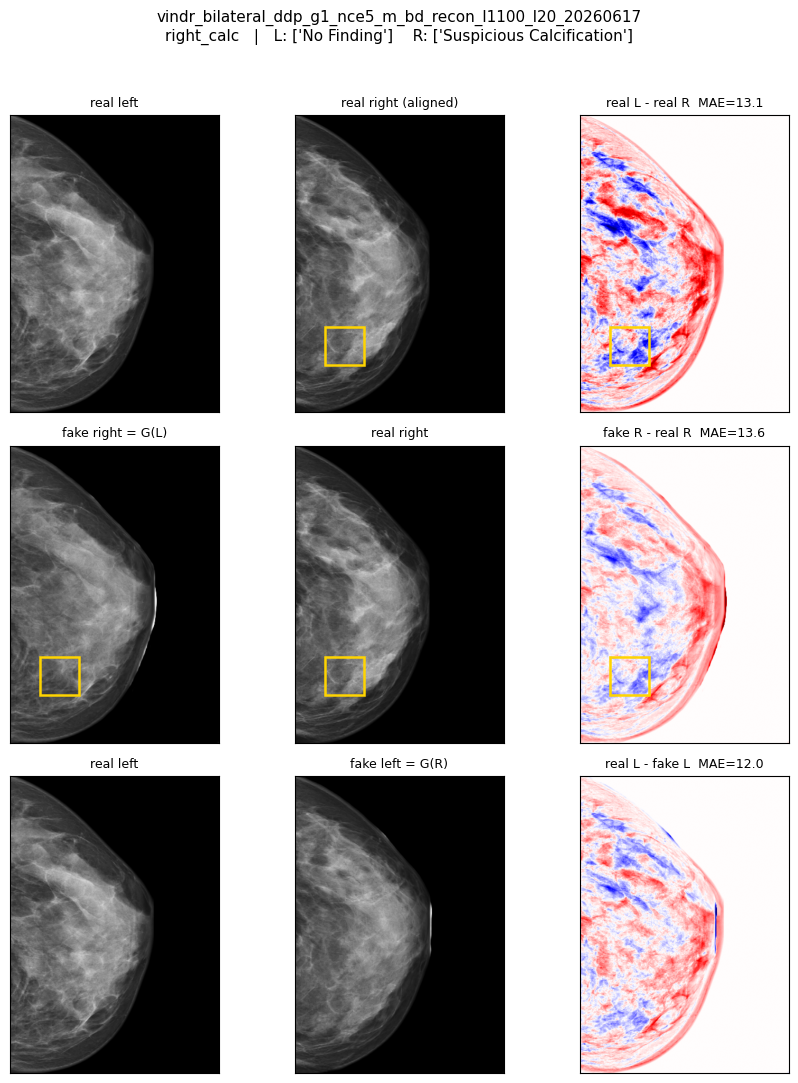

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617 / right_calc  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260617/right_calc/study_grid.png


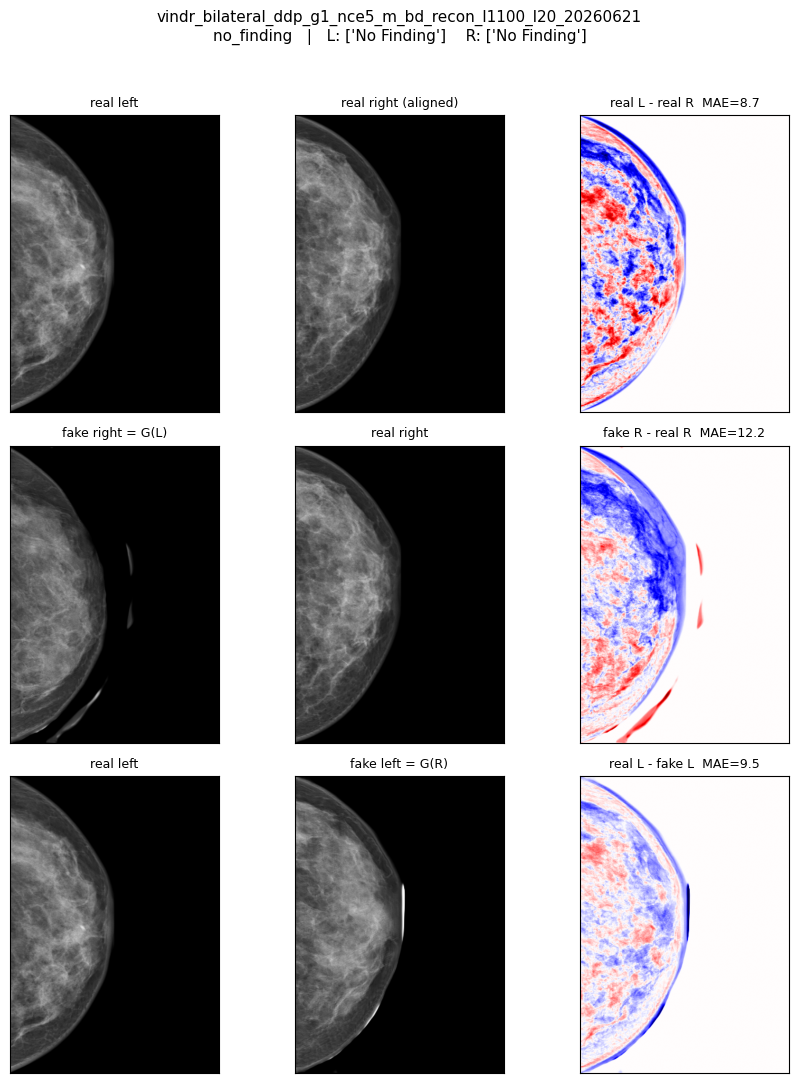

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621 / no_finding  (right boxes: 0, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621/no_finding/study_grid.png


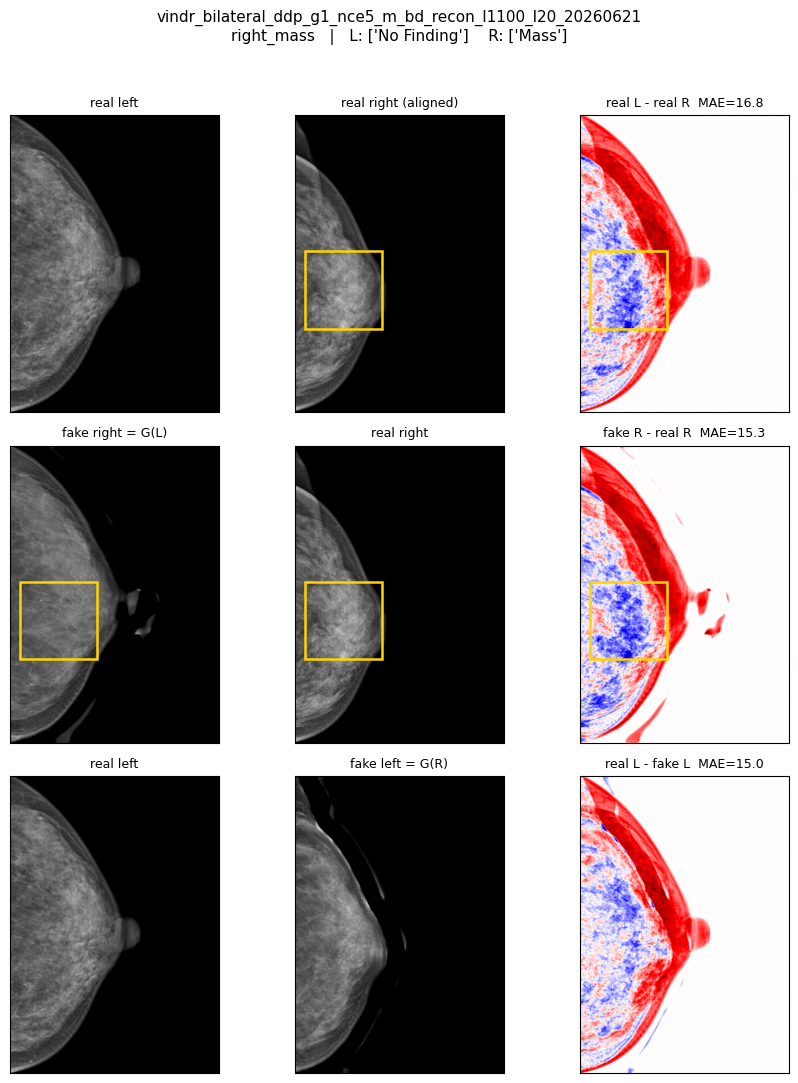

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621 / right_mass  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621/right_mass/study_grid.png


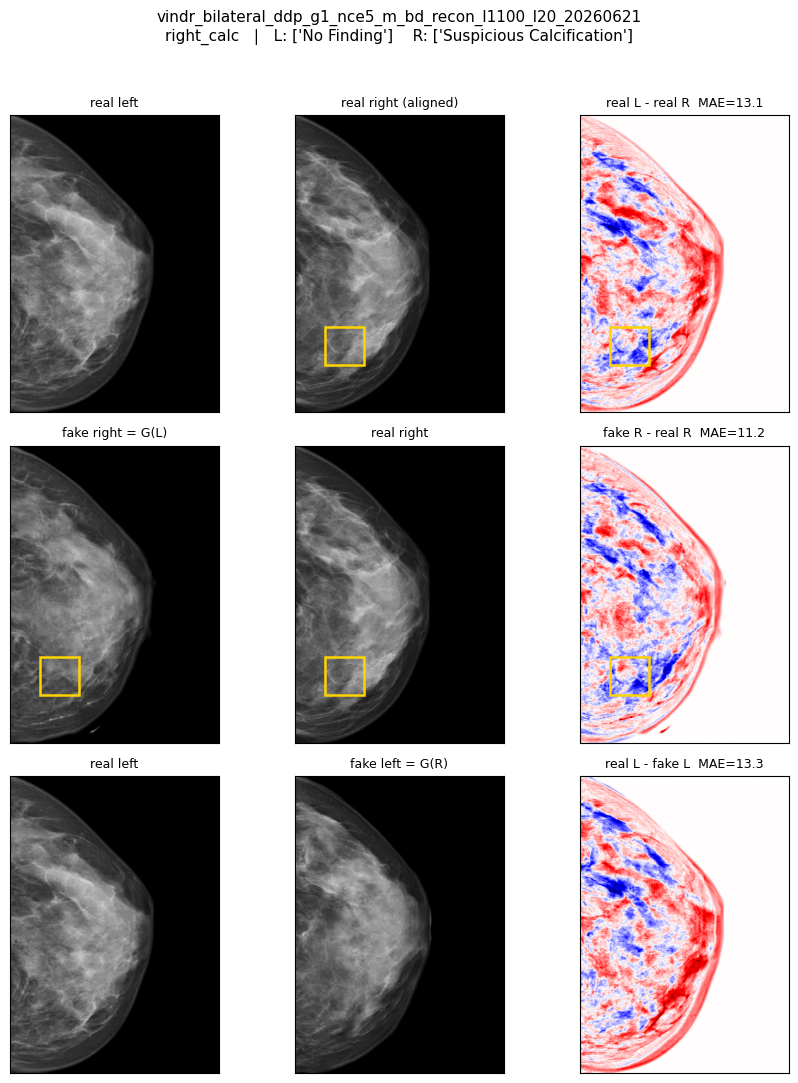

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621 / right_calc  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l1100_l20_20260621/right_calc/study_grid.png


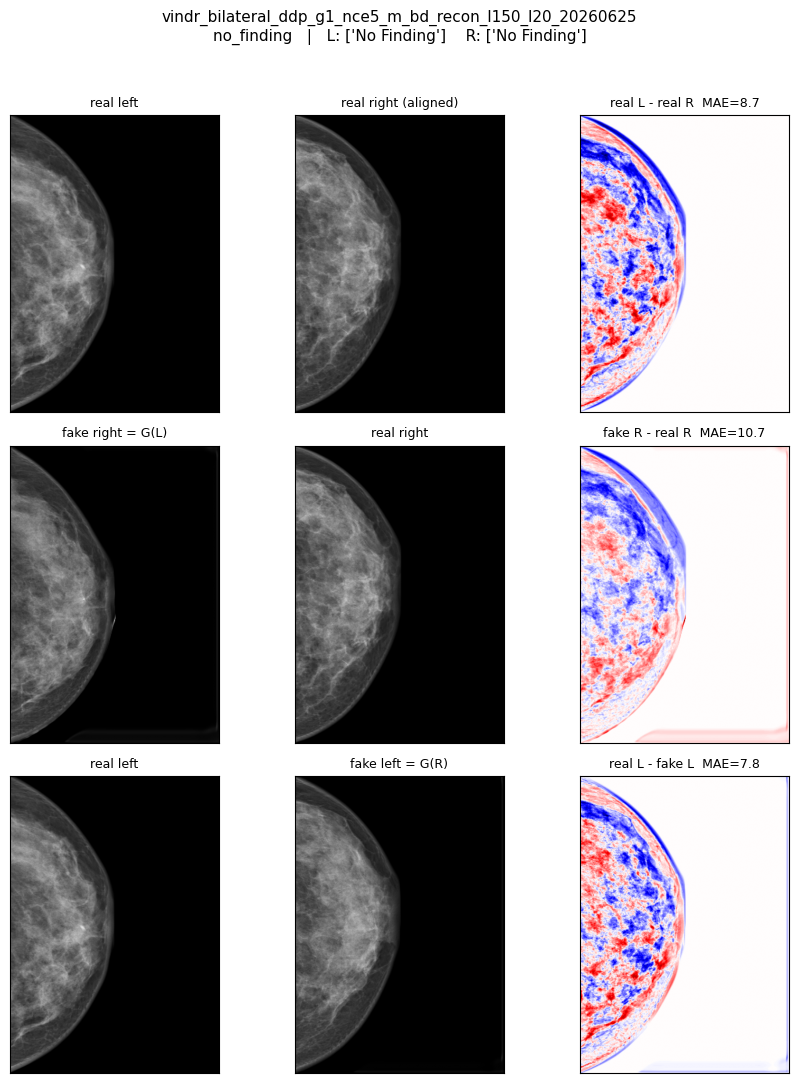

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625 / no_finding  (right boxes: 0, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625/no_finding/study_grid.png


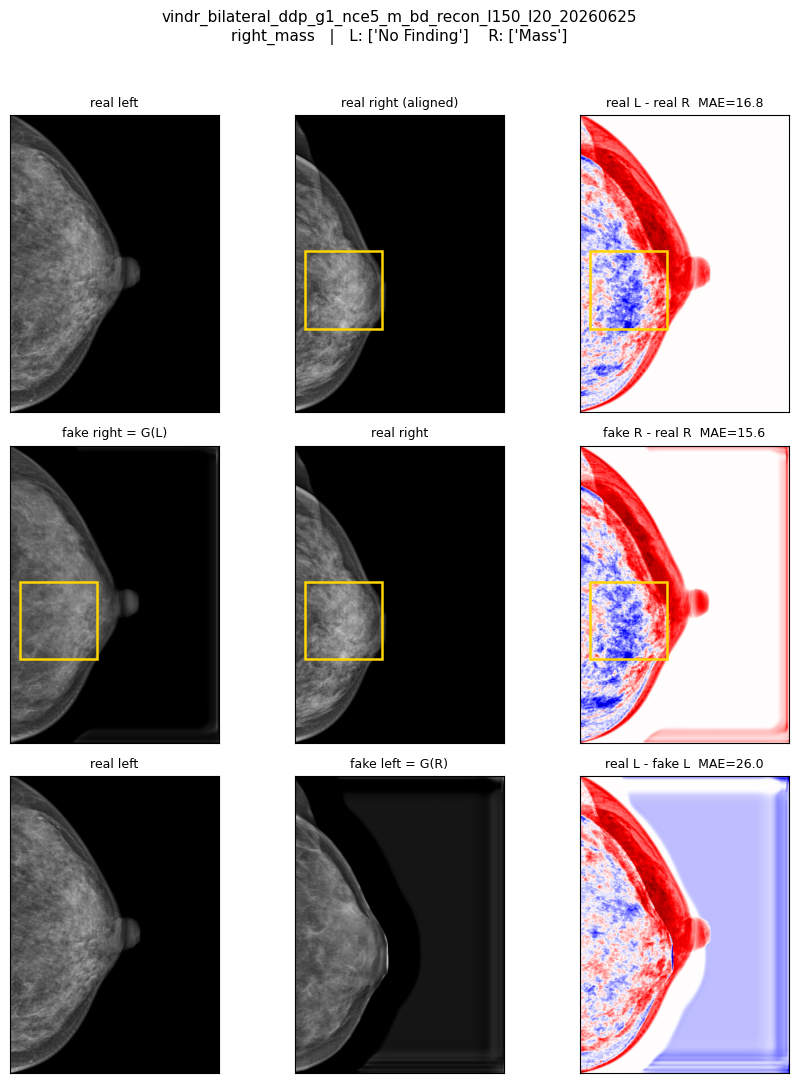

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625 / right_mass  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625/right_mass/study_grid.png


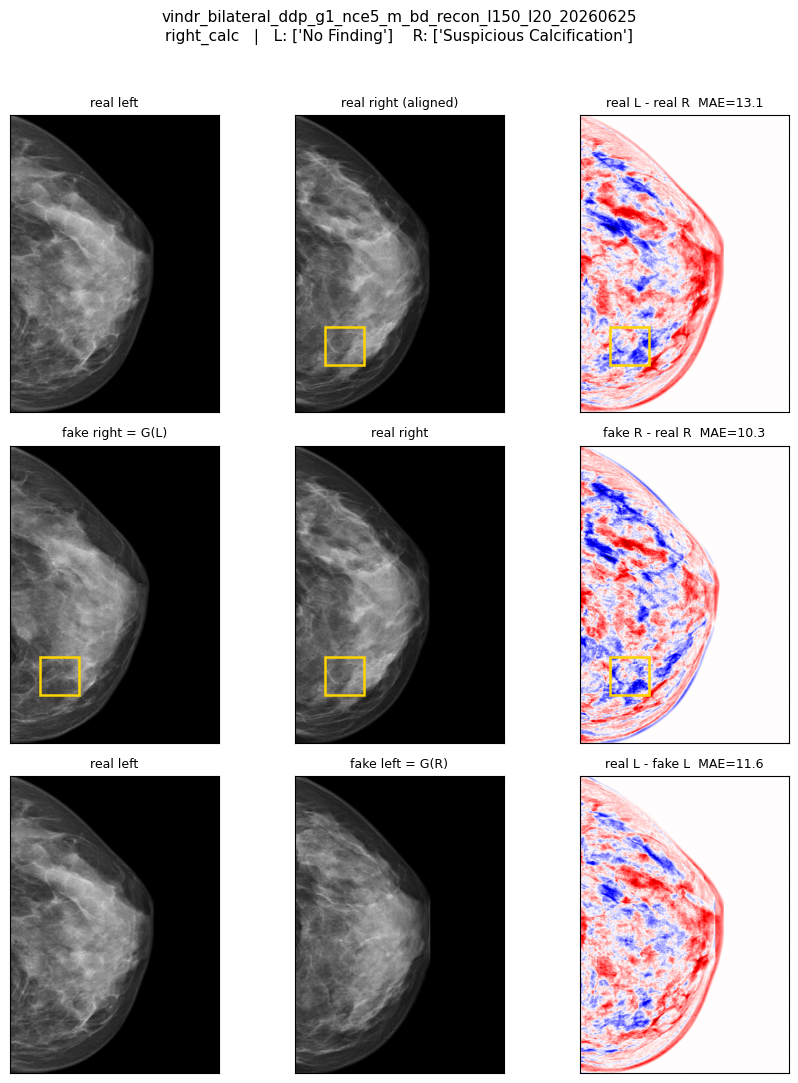

shown vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625 / right_calc  (right boxes: 1, left boxes: 0)  -> /home/valery/phd/contrastive-unpaired-translation/laterality_samples/vindr_bilateral_ddp_g1_nce5_m_bd_recon_l150_l20_20260625/right_calc/study_grid.png


In [5]:
# ============================ 4. Display (per-study 3x3 grid) ============================
# Re-loads the saved aligned-frame PNGs (so this cell is re-runnable without section 3) and,
# per model x study, draws:
#   row 0:  real left       | real right         | diff(real left, real right)   <- L/R asymmetry
#   row 1:  fake right=G(L)  | real right         | diff(fake right, real right)  <- L->R error
#   row 2:  real left        | fake left =G(R)    | diff(real left, fake left)    <- R->L error
# Finding boxes are mapped through the SAME geometry the model saw (resize -> flip -> crop) and
# drawn on every cell of the matching laterality: right (yellow), left (cyan).
import csv
from functools import lru_cache
from matplotlib.patches import Rectangle
from data.bilateral import _transform_boxes

BOX_COLOR = {"right": "#ffd400", "left": "#00e5ff"}  # yellow / cyan


@lru_cache(maxsize=1)
def _annot_by_image_id():
    # image_id -> {"h","w","boxes":[(xmin,ymin,xmax,ymax)...], "cats": "['...']"}.
    # Boxes live in the CSV's (height,width) pixel space (the stored/resized PNG).
    out = {}
    with open(ANNOTATIONS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            rec = out.setdefault(row["image_id"],
                                 {"h": None, "w": None, "boxes": [], "cats": row["finding_categories"]})
            if rec["h"] is None and row["height"] and row["width"]:
                rec["h"], rec["w"] = int(float(row["height"])), int(float(row["width"]))
            if row["xmin"]:  # a finding row carrying a localized box
                try:
                    rec["boxes"].append((float(row["xmin"]), float(row["ymin"]),
                                         float(row["xmax"]), float(row["ymax"])))
                except ValueError:
                    pass
    return out


def aligned_boxes(image_id, cfg, flip, out_h, out_w):
    """CSV finding boxes -> pixel boxes in the displayed (aligned, cropped) frame.

    The CSV stores boxes in the resized-PNG space (its height/width columns); the model
    frame additionally resizes that to bilateral_size and then flips/crops. So scale
    CSV->bilateral first, then let _transform_boxes apply the exact flip+crop that
    _load_image applied to the image. Returns [(x0,y0,x1,y1), ...] in output pixels.
    """
    rec = _annot_by_image_id().get(image_id)
    if not rec or not rec["boxes"] or not rec["h"]:
        return []
    bil_h, bil_w = cfg["bilateral_size"]
    sx, sy = bil_w / rec["w"], bil_h / rec["h"]
    scaled = [(x0 * sx, y0 * sy, x1 * sx, y1 * sy) for (x0, y0, x1, y1) in rec["boxes"]]
    norm = _transform_boxes(scaled, cfg["bilateral_size"], flip, cfg["crop_width"])
    return [(x0 * out_w, y0 * out_h, x1 * out_w, y1 * out_h) for (x0, y0, x1, y1) in norm]


def _draw_boxes(ax, boxes_by_side):
    for side, boxes in boxes_by_side.items():
        for x0, y0, x1, y1 in boxes:
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                   fill=False, edgecolor=BOX_COLOR[side], linewidth=1.8))


def _load_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return None if img is None else img.astype(np.float32)


def _show(ax, img, title, boxes_by_side):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    _draw_boxes(ax, boxes_by_side)


def _show_diff(ax, a, b, title, boxes_by_side):
    d = (a - b) / 255.0                                  # signed diff in [-1, 1]
    v = max(float(np.abs(d).max()), 1e-3)
    ax.imshow(d, cmap="seismic", vmin=-v, vmax=v)
    ax.set_title(f"{title}  MAE={float(np.abs(a - b).mean()):.1f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    _draw_boxes(ax, boxes_by_side)


_FNAMES = ("real_left.png", "real_right_aligned.png",
           "fake_right_from_left.png", "fake_left_from_right.png")

for m in MODELS:
    name = m["name"]
    cfg = parse_train_opt(name)
    for s in SAMPLES:
        out_dir = OUTPUT_DIR / name / s["label"]
        imgs = {f: _load_gray(out_dir / f) for f in _FNAMES}
        if any(v is None for v in imgs.values()):
            print(f"SKIP {name} / {s['label']} - missing PNGs in {out_dir} (run section 3 first)")
            continue
        real_left, real_right = imgs["real_left.png"], imgs["real_right_aligned.png"]
        fake_right, fake_left = imgs["fake_right_from_left.png"], imgs["fake_left_from_right.png"]
        out_h, out_w = real_left.shape

        # finding boxes in the displayed frame, per laterality
        rb = aligned_boxes(s["right_image_id"], cfg, flip=cfg["flip_right"], out_h=out_h, out_w=out_w)
        lb = aligned_boxes(s["left_image_id"],  cfg, flip=False,            out_h=out_h, out_w=out_w)
        R, L, BOTH = {"right": rb}, {"left": lb}, {"right": rb, "left": lb}

        fig, ax = plt.subplots(3, 3, figsize=(9, 11))
        _show(ax[0, 0], real_left,  "real left",            L)
        _show(ax[0, 1], real_right, "real right (aligned)", R)
        _show_diff(ax[0, 2], real_left, real_right, "real L - real R", BOTH)

        _show(ax[1, 0], fake_right, "fake right = G(L)",    R)
        _show(ax[1, 1], real_right, "real right",           R)
        _show_diff(ax[1, 2], fake_right, real_right, "fake R - real R", R)

        _show(ax[2, 0], real_left,  "real left",            L)
        _show(ax[2, 1], fake_left,  "fake left = G(R)",     L)
        _show_diff(ax[2, 2], real_left, fake_left, "real L - fake L", L)

        annot = _annot_by_image_id()
        lcats = annot.get(s["left_image_id"],  {}).get("cats", "?")
        rcats = annot.get(s["right_image_id"], {}).get("cats", "?")
        fig.suptitle(f"{name}\n{s['label']}   |   L: {lcats}    R: {rcats}", fontsize=11)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(out_dir / "study_grid.png", dpi=120, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"shown {name} / {s['label']}  (right boxes: {len(rb)}, left boxes: {len(lb)})"
              f"  -> {out_dir / 'study_grid.png'}")